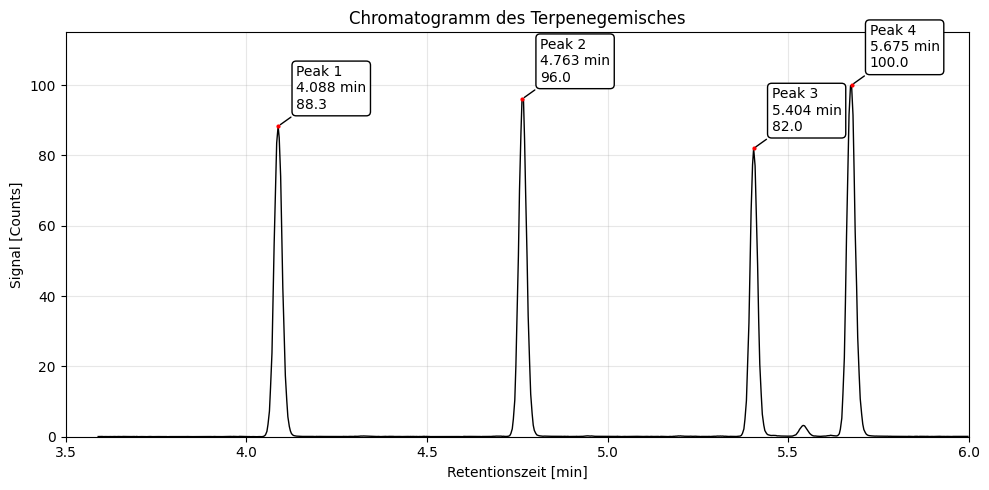

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =========================
# 1) CSV-Datei einlesen
# =========================
df = pd.read_csv(
    "Test.csv",
    comment="#",
    sep=",",
    header=None,
    names=["Point", "X", "Y"]
)

# =========================
# 2) Störzeichen entfernen & in Zahlen umwandeln
# =========================
df["X"] = df["X"].astype(str).str.replace(";", "", regex=False)
df["Y"] = df["Y"].astype(str).str.replace(";", "", regex=False)

df["X"] = pd.to_numeric(df["X"], errors="coerce")
df["Y"] = pd.to_numeric(df["Y"], errors="coerce")

df = df.dropna(subset=["X", "Y"])

# =========================
# 3) Peaks finden (nur im Bereich 3.5–6 min)
# =========================
df_plot = df[(df["X"] >= 3.5) & (df["X"] <= 6)]

peaks, _ = find_peaks(df_plot["Y"], prominence=5)

# 4 größte Peaks auswählen
peak_values = df_plot["Y"].iloc[peaks]
top4 = peak_values.nlargest(4).index

# Nach Zeit sortieren
top4_sorted = top4.sort_values(key=lambda x: df_plot["X"].loc[x])

# =========================
# 4) Plot
# =========================
plt.figure(figsize=(10, 5))
plt.plot(df_plot["X"], df_plot["Y"], linewidth=1, color="black")

plt.xlabel("Retentionszeit [min]")
plt.ylabel("Signal [Counts]")
plt.title("Chromatogramm des Terpenegemisches")
plt.grid(True, alpha=0.3)

# =========================
# 5) Peaks markieren + beschriften
# =========================
for i, p in enumerate(top4_sorted, start=1):
    x = df_plot["X"].loc[p]
    y = df_plot["Y"].loc[p]

    # Punkt markieren
    plt.plot(x, y, "ro", markersize=2)

    # Textposition
    text_x = x + 0.05
    text_y = y + df_plot["Y"].max() * 0.05

    # Linie + Text
    plt.annotate(
        f"Peak {i}\n{x:.3f} min\n{y:.1f}",
        xy=(x, y),
        xytext=(text_x, text_y),
        arrowprops=dict(arrowstyle="-", color="black"),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
        fontsize=10
    )

# Achsenbegrenzung
plt.xlim(3.5, 6)
plt.ylim(0, df_plot["Y"].max() * 1.15)

plt.tight_layout()
plt.show()


--- Peakflächen ---
Peak 1: 2.38 Counts·min
Peak 2: 2.52 Counts·min
Peak 3: 2.03 Counts·min
Peak 4: 2.82 Counts·min


/var/folders/hd/f5n6dywd28bgfnhwhdf_g_pw0000gn/T/ipykernel_67998/1922039201.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(y_vals, x_vals)   # numerische Integration


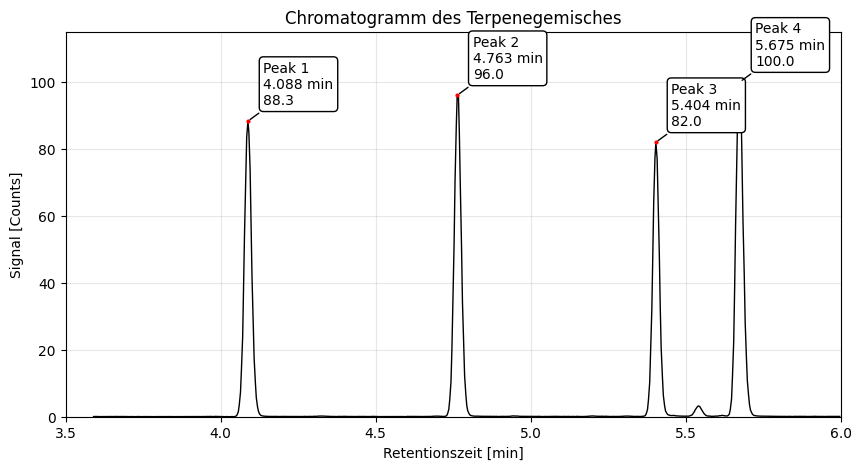

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =========================
# 1) CSV-Datei einlesen
# =========================
df = pd.read_csv(
    "Test.csv",
    comment="#",
    sep=",",
    header=None,
    names=["Point", "X", "Y"]
)

# =========================
# 2) Störzeichen entfernen & in Zahlen umwandeln
# =========================
df["X"] = df["X"].astype(str).str.replace(";", "", regex=False)
df["Y"] = df["Y"].astype(str).str.replace(";", "", regex=False)

df["X"] = pd.to_numeric(df["X"], errors="coerce")
df["Y"] = pd.to_numeric(df["Y"], errors="coerce")

df = df.dropna(subset=["X", "Y"])

# =========================
# 3) Peaks finden (nur im Bereich 3.5–6 min)
# =========================
df_plot = df[(df["X"] >= 3.5) & (df["X"] <= 6)]

peaks, _ = find_peaks(df_plot["Y"], prominence=5)

# 4 größte Peaks auswählen
peak_values = df_plot["Y"].iloc[peaks]
top4 = peak_values.nlargest(4).index

# Nach Zeit sortieren
top4_sorted = top4.sort_values(key=lambda x: df_plot["X"].loc[x])

# =========================
# 4) Plot
# =========================
plt.figure(figsize=(10, 5))
plt.plot(df_plot["X"], df_plot["Y"], linewidth=1, color="black")

plt.xlabel("Retentionszeit [min]")
plt.ylabel("Signal [Counts]")
plt.title("Chromatogramm des Terpenegemisches")
plt.grid(True, alpha=0.3)

# =========================
# 5) Peaks markieren + beschriften
# =========================
for i, p in enumerate(top4_sorted, start=1):
    x = df_plot["X"].loc[p]
    y = df_plot["Y"].loc[p]

    # Punkt markieren
    plt.plot(x, y, "ro", markersize=2)

    # Textposition
    text_x = x + 0.05
    text_y = y + df_plot["Y"].max() * 0.05

    # Linie + Text
    plt.annotate(
        f"Peak {i}\n{x:.3f} min\n{y:.1f}",
        xy=(x, y),
        xytext=(text_x, text_y),
        arrowprops=dict(arrowstyle="-", color="black"),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
        fontsize=10
    )

# Achsenbegrenzung
plt.xlim(3.5, 6)
plt.ylim(0, df_plot["Y"].max() * 1.15)

# 6) Peakflächen berechnen
# =========================
results = peak_widths(df_plot["Y"], peaks, rel_height=0.95)

# Linke & rechte Integrationsgrenzen (Index)
left_ips = results[2].astype(int)
right_ips = results[3].astype(int)

peak_areas = {}

for i, (p, l, r) in enumerate(zip(peaks, left_ips, right_ips), start=1):
    x_vals = df_plot["X"].iloc[l:r]
    y_vals = df_plot["Y"].iloc[l:r]

    area = np.trapz(y_vals, x_vals)   # numerische Integration
    peak_areas[f"Peak {i}"] = area

# =========================
# 7) Ausgabe der Peakflächen
# =========================
print("\n--- Peakflächen ---")
for k, v in peak_areas.items():
    print(f"{k}: {v:.2f} Counts·min")

/var/folders/hd/f5n6dywd28bgfnhwhdf_g_pw0000gn/T/ipykernel_67998/98493989.py:86: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(y_vals, x_vals)


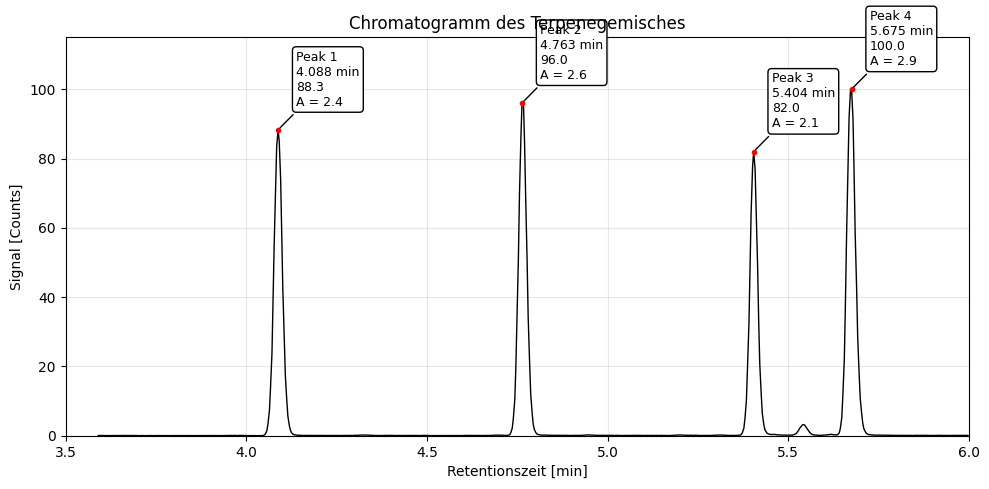


--- Peakflächen (Counts·min) ---
Peak 1: 2.40
Peak 2: 2.56
Peak 3: 2.05
Peak 4: 2.86


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths

# =========================
# 1) CSV-Datei einlesen
# =========================
df = pd.read_csv(
    "Test.csv",      # Dateiname anpassen falls nötig
    comment="#",
    sep=",",
    header=None,
    names=["Point", "X", "Y"]
)

# =========================
# 2) Störzeichen entfernen & in Zahlen umwandeln
# =========================
df["X"] = df["X"].astype(str).str.replace(";", "", regex=False)
df["Y"] = df["Y"].astype(str).str.replace(";", "", regex=False)

df["X"] = pd.to_numeric(df["X"], errors="coerce")
df["Y"] = pd.to_numeric(df["Y"], errors="coerce")

# Zeilen mit NaN in X oder Y rausschmeißen
df = df.dropna(subset=["X", "Y"])

# =========================
# 3) Bereich 3.5–6 min auswählen
# =========================
df_plot = df[(df["X"] >= 3.5) & (df["X"] <= 6)].copy()

# =========================
# 4) Peaks finden
# =========================
# Erst mal alle Peaks in diesem Bereich (Prominenz anpassen, falls nötig)
all_peaks, _ = find_peaks(df_plot["Y"], prominence=5)

# 4 höchsten Peaks auswählen
peak_values = df_plot["Y"].iloc[all_peaks]
top4_indices = peak_values.nlargest(4).index           # Index in df_plot
# nach Zeit sortieren (links → rechts)
top4_sorted = top4_indices.to_series().sort_values(key=lambda x: df_plot["X"].loc[x])

# =========================
# 5) Plot
# =========================
plt.figure(figsize=(10, 5))
plt.plot(df_plot["X"], df_plot["Y"], linewidth=1, color="black")

plt.xlabel("Retentionszeit [min]")
plt.ylabel("Signal [Counts]")
plt.title("Chromatogramm des Terpenegemisches")
plt.grid(True, alpha=0.3)

ymax = df_plot["Y"].max()

# =========================
# 6) Peakflächen berechnen + Peaks markieren
# =========================

peak_areas = {}

# Peakbreiten für genau diese 4 Peaks bestimmen
# Dazu brauchen wir die Positionen als Integer-Array relativ zu df_plot
peak_positions = df_plot.index.get_indexer(top4_sorted)
results = peak_widths(df_plot["Y"].to_numpy(), peak_positions, rel_height=0.95)

left_ips = results[2]
right_ips = results[3]

for i, (df_idx, pos, l_ip, r_ip) in enumerate(
    zip(top4_sorted, peak_positions, left_ips, right_ips), start=1
):
    x_peak = df_plot.loc[df_idx, "X"]
    y_peak = df_plot.loc[df_idx, "Y"]

    # Integrationsbereich [left, right] in echten Indizes von df_plot
    l = int(np.floor(l_ip))
    r = int(np.ceil(r_ip))
    x_vals = df_plot["X"].iloc[l:r]
    y_vals = df_plot["Y"].iloc[l:r]

    # Fläche per Trapezregel
    area = np.trapz(y_vals, x_vals)
    peak_areas[f"Peak {i}"] = area

    # Peak im Plot markieren
    plt.plot(x_peak, y_peak, "ro", markersize=3)

    # Textposition
    text_x = x_peak + 0.05
    text_y = y_peak + 0.07 * ymax

    # Annotation mit Linie + Text (RT, Höhe, Fläche)
    plt.annotate(
        f"Peak {i}\n{x_peak:.3f} min\n{y_peak:.1f}\nA = {area:.1f}",
        xy=(x_peak, y_peak),
        xytext=(text_x, text_y),
        arrowprops=dict(arrowstyle="-", color="black"),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
        fontsize=9
    )

# Achsenbegrenzung
plt.xlim(3.5, 6)
plt.ylim(0, ymax * 1.15)

plt.tight_layout()
plt.show()

# =========================
# 7) Peakflächen im Terminal ausgeben
# =========================
print("\n--- Peakflächen (Counts·min) ---")
for name, area in peak_areas.items():
    print(f"{name}: {area:.2f}")